In [1]:
import os
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
#import matplotlib.pyplot as plt
#import torchvision.models as models

from utils.tools import *
from munch import munchify
from torch import nn as nnfilename
from torch.distributions import Categorical

In [2]:
def get_tte_model(model, in_ch=2048, out_ch=2, device="cuda"):
    '''
        path (string): model path
        in_ch (int): input channel from the penultimate convolutional feature map
        out_ch (int): the number of classes
    '''

    fc = model.fc.state_dict()

    out_ch = fc["weight"].size(0)
    finalConv = nn.Conv2d(in_ch, out_ch, 1, 1)

    ## get the weights from the fc layer
    finalConv.load_state_dict({"weight":fc["weight"].view(out_ch, in_ch, 1, 1), "bias":fc["bias"]})
    tmp_model = nn.Sequential(*list(model.children())[:-2]+[finalConv])
    
    tmp_model = tmp_model.to(device)
    tmp_model.eval()
    return tmp_model

# Chest X Ray dataset

## Black-box CNN Model

In [3]:
model_weight = './Model_weights/resnet_rsna_bin_best_validation_weights_acc.pt'
res_model = torch.load(model_weight, weights_only=False)
res_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
## From black-box to Test Time Explainable model
tte_model = get_tte_model(res_model, in_ch=2048, out_ch=2)
tte_model

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [57]:
## TTE-CAM: from black box to explainable CNNs

## Dataset

In [5]:
path = "./Samples_images/"
img_path = "./Samples_images/RSNA"

In [6]:
config = {'data': {'input_size': 512, 
                   'mean': [0.488974928855896, 0.488974928855896, 0.488974928855896],
                   'std': [0.2458493560552597, 0.2458493560552597, 0.2458493560552597]}
         }

cfg = munchify(config)

In [44]:
fnames = os.listdir(img_path)
print(fnames)

['f8767c5d-9024-43d9-9044-843f2cec00c7.png', 'd7545025-6654-4cc3-83d1-99a34476c72a.png', 'bce1a9aa-127b-4535-9e96-d1ca41d72e0c.png', 'bc45556d-61f2-43c6-b886-21bdc59542e7.png', '4b048bdc-0a0a-43ed-aa0d-5971e433874b.png', '719bb18b-a428-4fd8-9338-46f1187ffa5c.png']


In [45]:
df_bb = pd.read_csv('csv_files/all_bb_rsna.csv')

data = pd.read_csv('csv_files/test_rsna.csv')
df_disease = data[data.filename.isin(fnames)].reset_index(drop=True)

df_disease

,filename,x,y,width,height,level
0,4b048bdc-0a0a-43ed-aa0d-5971e433874b.png,637.0,276.0,188.0,282.0,1
1,d7545025-6654-4cc3-83d1-99a34476c72a.png,638.0,319.0,258.0,458.0,1
2,f8767c5d-9024-43d9-9044-843f2cec00c7.png,669.0,342.0,202.0,514.0,1
3,bc45556d-61f2-43c6-b886-21bdc59542e7.png,224.0,470.0,225.0,278.0,1
4,bce1a9aa-127b-4535-9e96-d1ca41d72e0c.png,300.0,228.0,236.0,586.0,1
5,719bb18b-a428-4fd8-9338-46f1187ffa5c.png,630.0,515.0,214.0,414.0,1


## Inference

d7545025-6654-4cc3-83d1-99a34476c72a.png 1


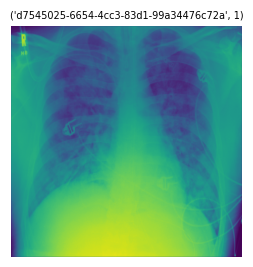

In [51]:
df_sample = df_disease.sample(1)
fname, level = df_sample.filename.tolist(), df_sample.level.tolist()

print(fname[0], level[0])

simple_plot(fname, level, img_path, fs=7)

In [52]:
ts_img, np_img = load_image(cfg, img_path, fname[0], xchest=True)
ts_img = ts_img.to('cuda')
print(ts_img.shape, np_img.shape)

activation, y_prob, y_class = get_tte_prediction(tte_model, ts_img)
y_prob, y_class

torch.Size([1, 3, 512, 512]) (512, 512, 3)


(1.0, 1)

## Visualization

In [53]:
s = 512
act = cv2.resize(activation[1], dsize=(s,s), interpolation=cv2.INTER_CUBIC)
print(act.min(), act.max())
overlay = get_overlay_img(np_img, act)

-29.37539 163.63727


In [54]:
list_img_act_overlay = [np_img, act, overlay]

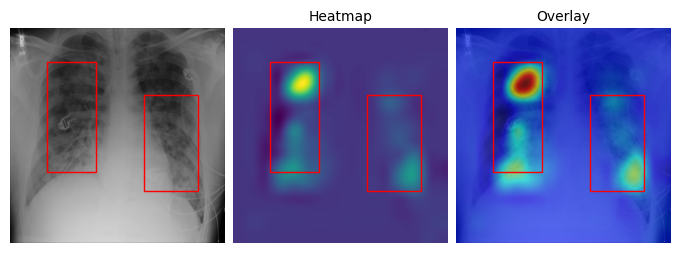

In [55]:
size = (1 * 6.69), (1 * 2.5)

dic_title = {0: f"{fname[0][:-4]}", 1:'Heatmap', 2:'Overlay'}

plot_img_heat_att(df_bb, list_img_act_overlay, dic_title, size, fs=10)

# Fundus dataset

In [98]:
## ToDo